# AM10 - Module: Intermediate 

## Lecture 10


### Learning objectives:
Second-order Ordinary Differential Equations: Euler's method, sinuisoidal functions, Runge-Kutta method.

_______________________________________________________________________

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Second-order differential equations


A second-order ODE is then given by:

$$ \frac{d^2 u}{dx^2} = g(x,u,u') $$

where $g(u,u',x)$ is a given function of the function $u$, its first derivative $$u'=\frac{du}{dx}, $$ and the variable $x$.  We also need to know the value of the function $u(x)$ and its derivative $u'(x)$ for some specific value of $x$ (the "initial" or "boundary" conditions), so that we can try to solve for the function $u(x)$ that satisfies this equation. 

#### 1a. Euler's method

An efficient is to use the three-point formula for the derivative twice, first for the function itself, and then for the first derivative:

$$\frac{u(x_{n+1})-u(x_{n-1})}{2\Delta x} = u'(x_n) \Rightarrow 
u(x_{n+1})=u(x_{n-1}) + 2 \; \Delta x \; u'(x_n)$$



$$\frac{u'(x_{n+1})-u'(x_{n-1})}{2\Delta x} = u''(x_n) =  g(x_n, u(x_n), u'(x_n)) \Rightarrow
u'(x_{n+1})=u'(x_{n-1}) + 2 \; \Delta x \; g(x_n, u(x_n), u'(x_n))$$

because both these expressions involve the small quantity $\Delta x$ only to the first power. The only problem is that now we need not only $u(x_0)$ and $u'(x_0)$, the intitial values, to get the iterative solution started, but also the values $u(x_1)$ and $u'(x_1)$, which are presumably not known.  These can be obtained by extrapolation:

$$\frac{u(x_1)-u(x_0)}{\Delta x} = u'(x_0)\Rightarrow u(x_1) = u(x_0) + \Delta x \; u'(x_0)$$

$$\frac{u'(x_1)-u'(x_0)}{\Delta x} = u''(x_0) = g(x_0, u_0, u'_0) 
\Rightarrow u'(x_1) = u'(x_0) + \Delta x \cdot g(x_0, u_0, u'_0)$$

#### Example:

We'll try the following second-order equation:

$$\frac{d^2 u}{dx^2} = x u' - 4 u$$

with $x_0=-1$, $u(x_0)=-2$, $u'(x_0)=8$. In this case $g(x,u,u') = x u'-4 u$.

The solution of this equation is:

$$u(x) = x^4 - 6 x^2 + 3$$

as can be easily checked.  We compare below the numerical with the exact solution.

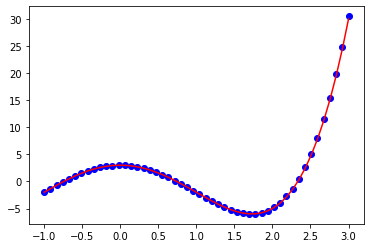

In [3]:
Nx=50
xmin=-1.0
xmax=3.0

x=np.linspace(xmin,xmax,Nx)
dx=x[1]-x[0]
dx2=2.0*dx

uf=np.zeros(Nx)
ud=np.zeros(Nx)
gf=np.zeros(Nx)

utrue=x**4 - 6*x**2 +3

uf[0]=-2.0
ud[0]=8.0
gf[0]=x[0]*ud[0]-4*uf[0]

uf[1]=uf[0]+ud[0]*dx
ud[1]=ud[0]+gf[0]*dx

for n in range(1,Nx-1):
    gf[n]=x[n]*ud[n]-4*uf[n]
    ud[n+1]=ud[n-1]+dx2*gf[n]
    uf[n+1]=uf[n-1]+dx2*ud[n]
    
plt.plot(x,uf,'bo')
plt.plot(x,utrue,'r-')
plt.show()

### 2. An eigenfunction problem

A very important case is:

$$ \frac{d^2 u}{dx^2} = -a^2 u \Rightarrow g(x,u,u') = -a^2 u  $$

where $a$ is a constant.  In this case, the differential operator $d^2/dx^2$ applied to the function $u(x)$ gives back the function times a constant, $-a^2$: this is an "eigenfunction" of the operator.  

There are two functions, namely the sine and cosine $\sin(ax), \cos(ax)$, which when multiplied by an arbitrary constant each $A$ or $B$, exactly satisfies the above equation, for any value of the given constant $a$. For a general solution, we then take a linear combination of these two possibilities:

$$u(x) = A \sin(ax) + B \cos(ax)$$

Thus, the only quantities we need to specify in order to have a complete solution are the values of the constants $A$ and $B$, that's why we need two pieces of information. These could be the values of the function $u(x)$ at two different points $x_1,x_2$, or the value of the function and its derivative $u'(x)$ at one point $x_0$, or some combination of these. 

For example, if we know $u(x_0) = u_0$ and $u'(x_0) = u'_0$ then we have:

$$ u_0 = A \sin(a x_0) + B \cos(a x_0), \; \; \; u'_0=a \left [ A \cos(a x_0) - B \sin(a x_0) \right ]$$

which is a system of two equations and two unknowns, $A$ and $B$.

For example, if $A=1$, $B=0$ and $x_0 = 0$ we have:

$$u_0 = A \sin(a x_0) = 0, \; \; \; u'_0= a A \cos(a x_0) = a, \; \; \; u(x) = \sin(x)$$

Conversely, if $A=0$, $B=1$ and $x_0 = 0$ we have:

$$u_0 = B \cos(a x_0) = 1, \; \; \; u'_0= -a B \sin(a x_0) = 0, \; \; \; u(x) = \cos(x)$$


In most cases we are not so lucky to know the function $u(x)$ that satisfies the equation up to some easily determined constants, so we resort to numerical solution. 

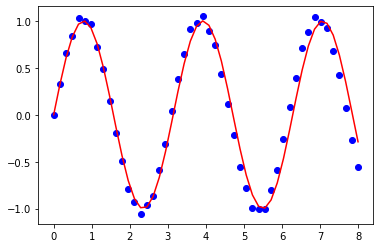

In [12]:
Nx=50
xmin=0
xmax=8
x=np.linspace(xmin,xmax,Nx)
dx=x[1]-x[0]
dx2=dx*2
uf1=np.zeros(Nx)
ud1=np.zeros(Nx)
gf1=np.zeros(Nx)

a=2.0
a2=a**2
Afact=1.0

uf1[0]=0.0
ud1[0]=Afact*a
ut1=Afact*np.sin(a*x)

gf1[0]=-a2*uf1[0]

uf1[1]=uf1[0]+dx*ud1[0]
ud1[1]=ud1[0]+dx*gf1[0]

for n in range(1,Nx-1):
    gf1[n]=-a2*uf1[n]
    ud1[n+1]=ud1[n-1]+dx2*gf1[n]
    uf1[n+1]=uf1[n-1]+dx2*ud1[n]
    
plt.plot(x,uf1,'bo')
plt.plot(x,ut1,'r-')
plt.show()



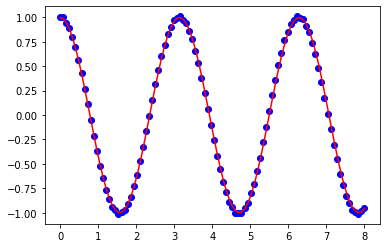

In [8]:
Nx=100
xmin=0
xmax=8
x=np.linspace(xmin,xmax,Nx)
dx=x[1]-x[0]
dx2=dx*2
uf2=np.zeros(Nx)
ud2=np.zeros(Nx)
gf2=np.zeros(Nx)

a=2.0
a2=a**2
Bfact=1.0

uf2[0]=Bfact
ud2[0]=0
ut2=Bfact*np.cos(a*x)

gf2[0]=-a2*uf2[0]

uf2[1]=uf2[0]+dx*ud2[0]
ud2[1]=ud2[0]+dx*gf2[0]

for n in range(1,Nx-1):
    gf2[n]=-a2*uf2[n]
    ud2[n+1]=ud2[n-1]+dx2*gf2[n]
    uf2[n+1]=uf2[n-1]+dx2*ud2[n]
    
plt.plot(x,uf2,'bo')
plt.plot(x,ut2,'r-')
plt.show()



#### 2a. The Runge-Kutta method

Starting with second-order equation, 
we can break it up to a couple of first-order equations:

$$\frac{d^2 u}{d x^2} = g(x,u,u')$$

$$\frac{d u}{d x} = v 
\Rightarrow 
\frac{d v}{dx} = \frac{d^2 u}{d x^2} = g(u,v,x) $$

Now we deal with the two coupled first-order equations, and use the second-order RK method:

$$\frac{d u}{dx} = v, \; \; \; \frac{d v}{dx} = g(x,u,v)$$

$$k^{(1)}_n =v_n, \; \; \; l^{(1)}_n =g(x_n,u_n,v_n)$$

$$k^{(2)}_n=v_n+\frac{h l^{(1)}_n}{2},\; \; \; 
l^{(2)}_n=g(x_n+\frac{h}{2},u_n+\frac{h k^{(1)}_n}{2}, v_n+\frac{h l^{(1)}_n}{2} )$$ 

$$k^{(3)}_n = v_n+h l^{(2)}_n, \; \; \; 
l^{(3)}_n = g(x_n+h,u_n+h k^{(2)}_n, v_n+h l^{(2)}_n)
$$ 

$$u_{n+1} = u_n + \frac{h}{4} \left [ k^{(1)}_n + 2 \; k^{(2)}_n + k^{(3)}_n \right ], \; \; \; 
v_{n+1} = v_n + \frac{h}{4} \left [ l^{(1)}_n + 2 \; l^{(2)}_n + l^{(3)}_n 
\right ]
$$



#### Graphical interpretation of the Runge-Kutta method

<img src="RK-2nd-order.png" alt="Drawing" style="width: 500px;"/>

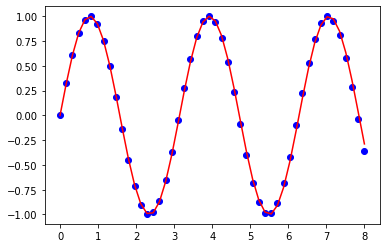

In [11]:
Nx=50
xmin=0
xmax=8
x=np.linspace(xmin,xmax,Nx)
dx=x[1]-x[0]
dx2=dx*2
uf3=np.zeros(Nx)
ud3=np.zeros(Nx)


a=2.0
a2=-a**2
Afact=1.0

uf3[0]=0.0
ud3[0]=Afact*a
ut3=Afact*np.sin(a*x)

for n in range(Nx-1):
    vn=ud3[n]
    un=uf3[n]
    
    k1=vn
    l1=a2*un
    
    k2=(vn+dx*l1/2)
    l2=a2*(un+dx*k1/2)
    
    k3=(vn+dx*l2)
    l3=a2*(un+dx*k2)
    
    uf3[n+1]=uf3[n]+dx*(k1+2*k2+k3)/4
    ud3[n+1]=ud3[n]+dx*(l1+2*l2+l3)/4
    
plt.plot(x,uf3,'bo')
plt.plot(x,ut3,'r-')
plt.show()
